In [ ]:
!pip install scipy
import pandas as pd
import numpy as np
from datetime import datetime
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import entropy

In [ ]:
df = pd.read_csv('C:/Users/shevc/Desktop/ai-impact-jobs-layoff-risk-dataset.csv')
df1 = pd.read_csv('C:/Users/shevc/Desktop/AI_Impact_on_Jobs_2030.csv')
df1.rename(columns={'Risk_Category': 'Layoff_Risk', 'Job_Title': 'Job_Role'}, inplace=True)
joined = df.merge(df1, how='outer', on=['Job_Role', 'Layoff_Risk', 'Education_Level'])
joined.drop(columns=[f'Skill_{i}' for i in range(1, 11)] + ['Years_Experience'], inplace=True)
joined.sort_values(by='Automation_Probability_2030', ascending=False).head(5)

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk,Average_Salary,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030
81338,NaN,Master's,NaN,NaN,Truck Driver,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,116030.0,0.79,0.88,0.95
3022,NaN,PhD,NaN,NaN,Customer Support,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,88880.0,0.73,1.18,0.95
2967,NaN,Master's,NaN,NaN,Customer Support,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,50746.0,0.95,0.87,0.95
47388,NaN,Bachelor's,NaN,NaN,Security Guard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,109557.0,0.28,0.90,0.95
46560,NaN,PhD,NaN,NaN,Retail Worker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,50242.0,0.54,1.27,0.95


In [ ]:
joined.shape

(82404, 20)

In [ ]:
joined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82404 entries, 0 to 82403
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          80038 non-null  float64
 1   Education_Level              82404 non-null  object 
 2   Years_of_Experience          80038 non-null  float64
 3   Industry                     80038 non-null  object 
 4   Job_Role                     82404 non-null  object 
 5   Company_Size                 80038 non-null  object 
 6   Job_Level                    80038 non-null  object 
 7   Routine_Task_Percentage      80038 non-null  float64
 8   Creativity_Requirement       80038 non-null  float64
 9   Human_Interaction_Level      80038 non-null  float64
 10  AI_Adoption_Level            80038 non-null  object 
 11  Number_of_AI_Tools_Used      80038 non-null  float64
 12  AI_Usage_Hours_Per_Week      80038 non-null  float64
 13  Tasks_Automated_

In [ ]:
print(f"Пропуски:\n{joined.isnull().sum()}")
print(f"Дубликаты: {joined.duplicated().sum()}")

Пропуски:
Age                             2366
Education_Level                    0
Years_of_Experience             2366
Industry                        2366
Job_Role                           0
Company_Size                    2366
Job_Level                       2366
Routine_Task_Percentage         2366
Creativity_Requirement          2366
Human_Interaction_Level         2366
AI_Adoption_Level               2366
Number_of_AI_Tools_Used         2366
AI_Usage_Hours_Per_Week         2366
Tasks_Automated_Percentage      2366
AI_Training_Hours               2366
Layoff_Risk                        0
Average_Salary                 18272
AI_Exposure_Index              18272
Tech_Growth_Factor             18272
Automation_Probability_2030    18272
dtype: int64
Дубликаты: 0


In [ ]:
num_cols = [
    'Age',
    'Years_of_Experience',
    'Routine_Task_Percentage',
    'Creativity_Requirement',
    'Human_Interaction_Level',
    'Number_of_AI_Tools_Used',
    'AI_Usage_Hours_Per_Week',
    'Tasks_Automated_Percentage',
    'AI_Training_Hours',
    'Average_Salary',
    'AI_Exposure_Index',
    'Tech_Growth_Factor',
    'Automation_Probability_2030'
]

category_cols = [
    'Education_Level',
    'Industry',
    'Job_Role',
    'Company_Size',
    'Job_Level',
    'AI_Adoption_Level',
    'Layoff_Risk'
]

In [ ]:
for col in num_cols:
    if joined[col].isna().sum() > 0:
        median_val = joined[col].median()
        joined[col] = joined[col].fillna(median_val)

for col in category_cols:
    if joined[col].notna().sum() > 0:
        mode_val = joined[col].mode()[0]
        joined[col] = joined[col].fillna(mode_val)

Повторная проверка:

In [ ]:
print(f"Пропуски:\n{joined.isnull().sum()}")
print(f"Дубликаты: {joined.duplicated().sum()}")

Пропуски:
Age                            0
Education_Level                0
Years_of_Experience            0
Industry                       0
Job_Role                       0
Company_Size                   0
Job_Level                      0
Routine_Task_Percentage        0
Creativity_Requirement         0
Human_Interaction_Level        0
AI_Adoption_Level              0
Number_of_AI_Tools_Used        0
AI_Usage_Hours_Per_Week        0
Tasks_Automated_Percentage     0
AI_Training_Hours              0
Layoff_Risk                    0
Average_Salary                 0
AI_Exposure_Index              0
Tech_Growth_Factor             0
Automation_Probability_2030    0
dtype: int64
Дубликаты: 0


In [ ]:
joined.describe()

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Average_Salary,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030
count,82404.000000,82404.000000,82404.000000,82404.000000,82404.000000,82404.000000,82404.000000,82404.000000,82404.000000,82404.000000,82404.000000,82404.000000,82404.000000
mean,40.624254,7.401315,44.118708,55.586331,69.234867,1.972574,5.279222,30.667043,9.784986,88309.835263,0.509842,1.001885,0.316244
std,11.320100,4.626413,20.444767,21.977301,20.891597,1.747720,5.094475,15.733069,10.807154,30620.477396,0.255899,0.256658,0.171391
min,21.000000,0.000000,10.000000,0.000000,20.000000,0.000000,0.000000,4.000000,0.000000,30030.000000,0.000000,0.500000,0.050000
25%,31.000000,4.000000,28.000000,41.000000,56.000000,1.000000,2.000000,19.000000,3.000000,66105.000000,0.310000,0.830000,0.200000
50%,41.000000,7.000000,42.000000,57.000000,74.000000,2.000000,4.000000,29.000000,7.000000,88639.000000,0.520000,1.010000,0.280000
75%,50.000000,10.000000,58.000000,72.000000,86.000000,2.000000,7.000000,40.000000,11.000000,107576.000000,0.700000,1.170000,0.420000
max,60.000000,32.000000,94.000000,100.000000,99.000000,10.000000,30.000000,93.000000,79.000000,149798.000000,1.000000,1.500000,0.950000


Визуализируем данные по зарплате, т.к. большой разброс в значениях:

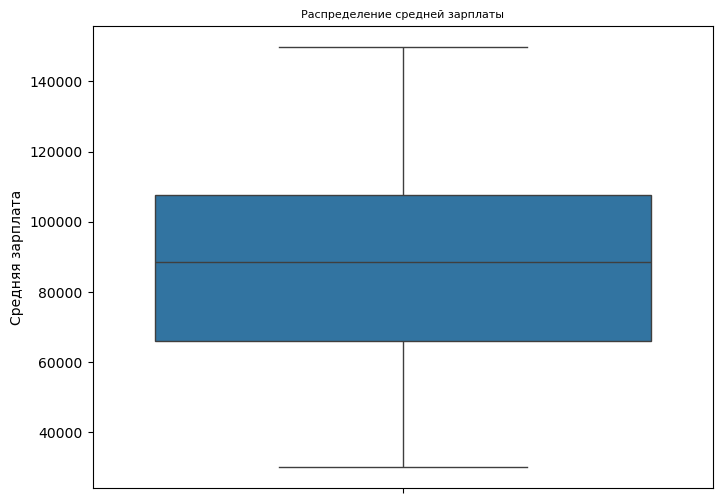

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=joined['Average_Salary'])
plt.title('Распределение средней зарплаты', fontsize=8)
plt.ylabel('Средняя зарплата')
plt.show()

## Числовые переменные: первичный анализ (статистика, уникальные значения), углубленный анализ (гистограмма (посмотреть распределение) + ящик с усами(проверить выбросы))

In [ ]:
joined[num_cols].describe().round(2)

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Average_Salary,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030
count,82404.00,82404.00,82404.00,82404.00,82404.00,82404.00,82404.00,82404.00,82404.00,82404.00,82404.00,82404.00,82404.00
mean,40.62,7.40,44.12,55.59,69.23,1.97,5.28,30.67,9.78,88309.84,0.51,1.00,0.32
std,11.32,4.63,20.44,21.98,20.89,1.75,5.09,15.73,10.81,30620.48,0.26,0.26,0.17
min,21.00,0.00,10.00,0.00,20.00,0.00,0.00,4.00,0.00,30030.00,0.00,0.50,0.05
25%,31.00,4.00,28.00,41.00,56.00,1.00,2.00,19.00,3.00,66105.00,0.31,0.83,0.20
50%,41.00,7.00,42.00,57.00,74.00,2.00,4.00,29.00,7.00,88639.00,0.52,1.01,0.28
75%,50.00,10.00,58.00,72.00,86.00,2.00,7.00,40.00,11.00,107576.00,0.70,1.17,0.42
max,60.00,32.00,94.00,100.00,99.00,10.00,30.00,93.00,79.00,149798.00,1.00,1.50,0.95


In [ ]:
for col in num_cols:
    print(f"\n{col}: {joined[col].unique()}")


Age: [41. 54. 37. 30. 43. 39. 51. 56. 42. 60. 55. 21. 40. 49. 47. 22. 52. 25.
 48. 46. 58. 34. 36. 35. 31. 23. 50. 44. 38. 33. 57. 59. 26. 45. 32. 29.
 28. 24. 53. 27.]

Years_of_Experience: [ 7.  9.  0. 13.  5.  4.  2. 16.  1. 12. 11.  6. 15. 10.  3. 14. 18.  8.
 21. 17. 24. 20. 19. 22. 23. 32. 25.]

Routine_Task_Percentage: [42. 75. 65. 80. 86. 74. 89. 55. 94. 93. 67. 76. 81. 87. 84. 82. 62. 88.
 92. 79. 70. 72. 57. 78. 64. 83. 68. 90. 85. 66. 91. 73. 77. 61. 71. 63.
 69. 44. 49. 60. 32. 22. 30. 48. 37. 23. 11. 19. 14. 21. 18. 29. 27. 59.
 31. 58. 20. 36. 10. 45. 53. 41. 34. 33. 16. 13. 38. 43. 15. 25. 28. 24.
 39. 56. 17. 52. 12. 51. 40. 50. 47. 26. 54. 46. 35.]

Creativity_Requirement: [ 57.  20.  26.   5.  29.  19.  39.  35.  15.   0.  23.  12.  36.  31.
  25.  11.   3.  47.  27.  14.   7.  13.   8.  33.  18.  34.  37.  21.
  41.   1.   2.   4.  32.  22.   9.   6.  10.  28.  17.  16.  42.  46.
  43.  40.  51.  24.  30.  63.  97.  68.  61.  64.  73.  87.  93. 100.
  77.  85.  70. 

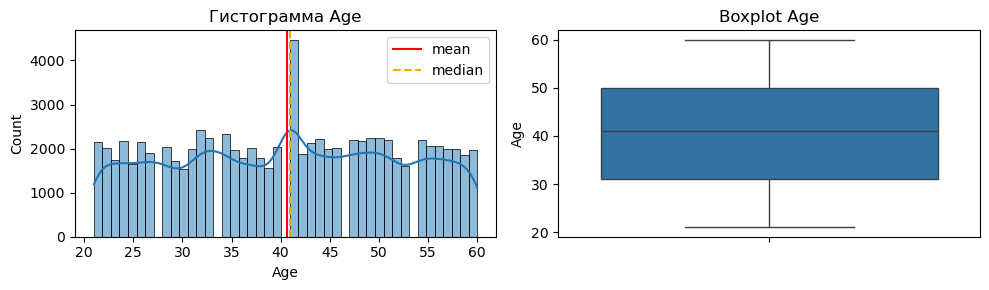

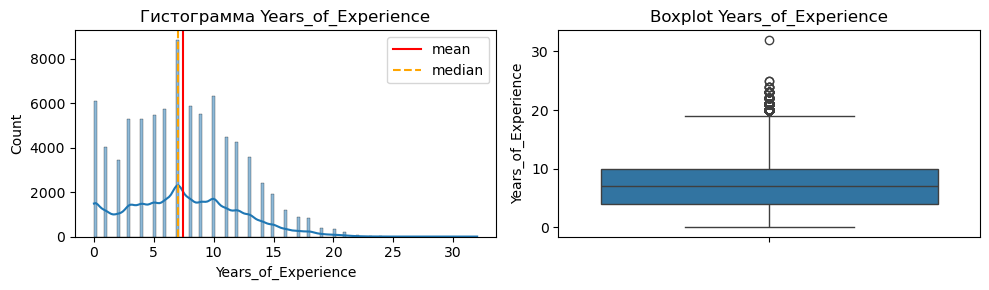

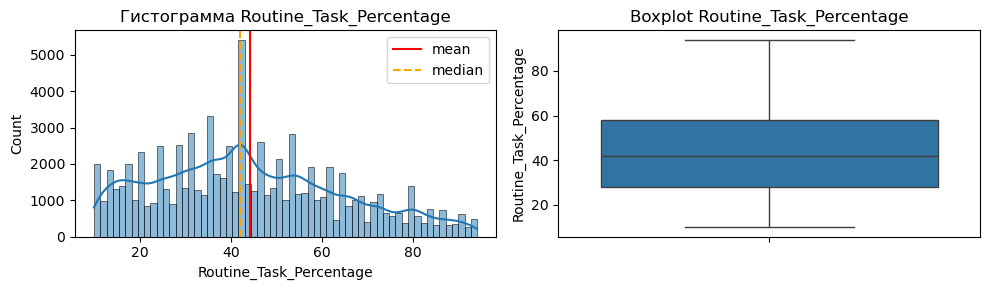

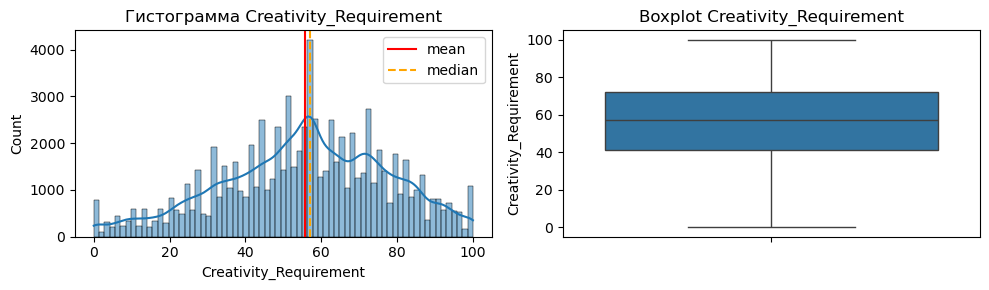

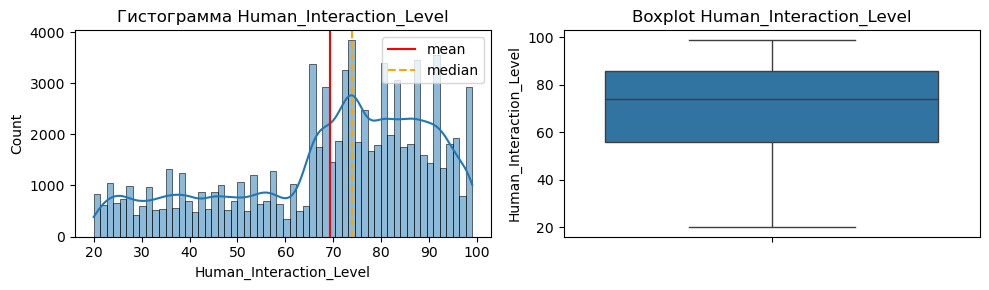

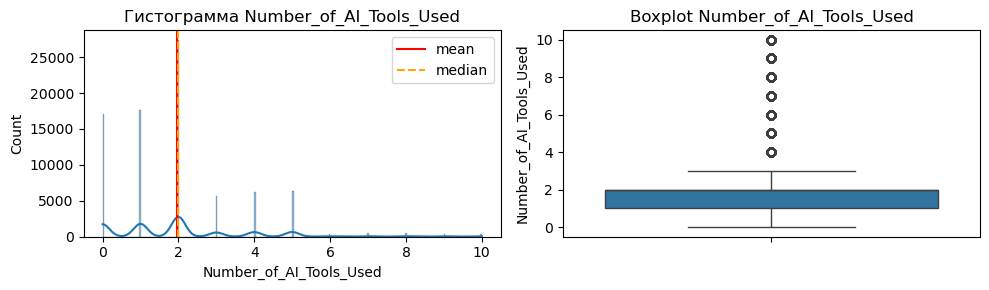

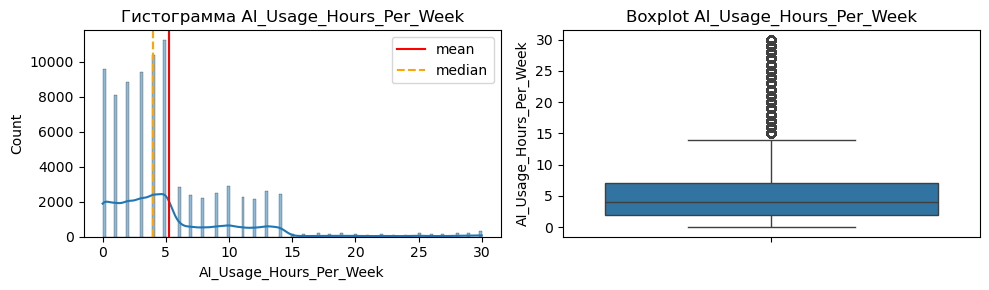

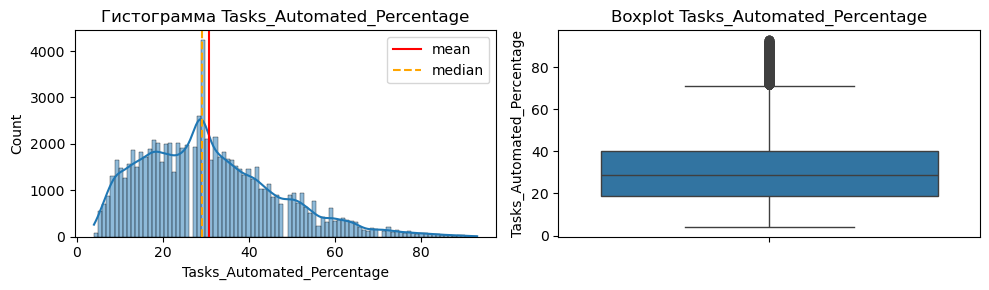

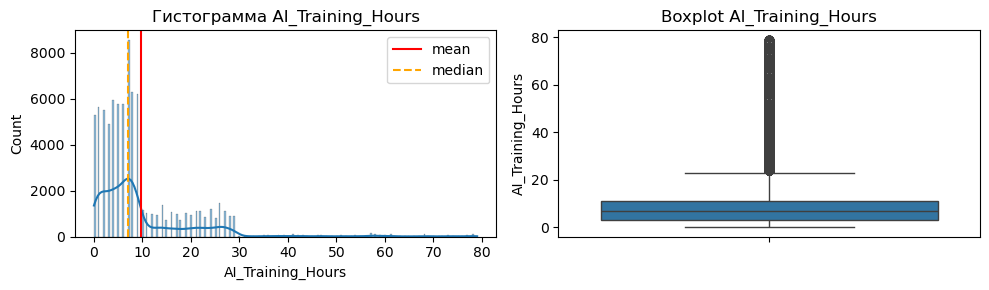

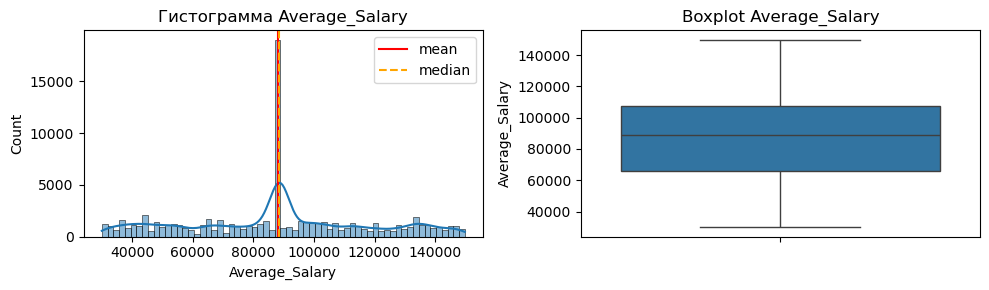

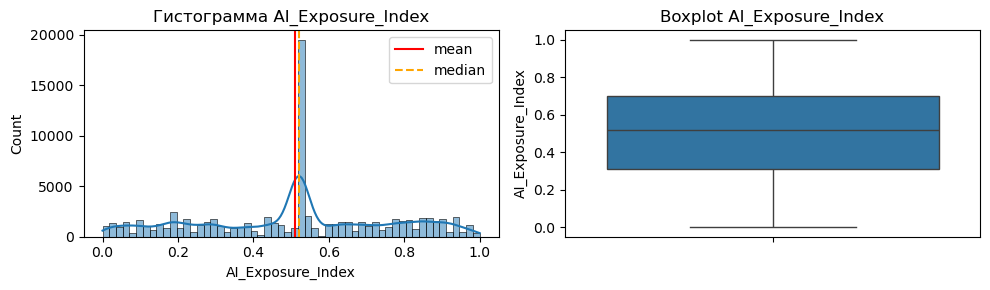

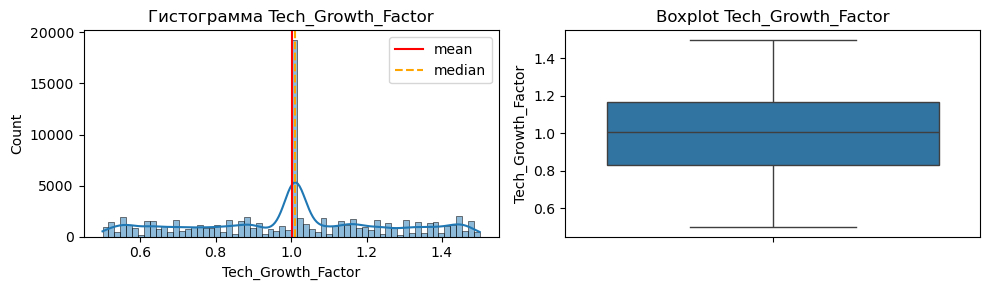

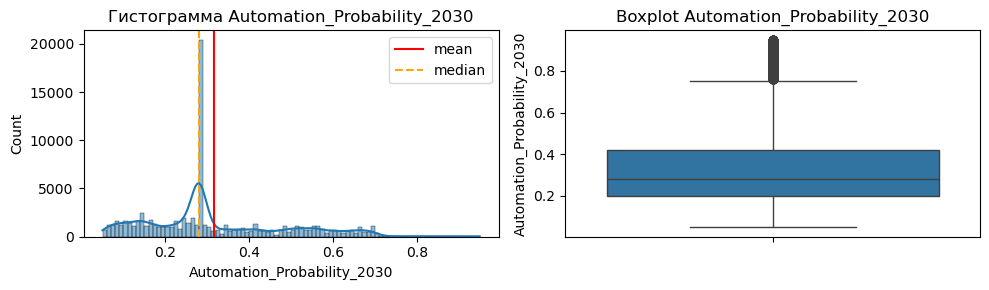

In [ ]:
for col in num_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

    sns.histplot(joined[col], bins='auto', kde=True, ax=ax1)
    ax1.axvline(joined[col].mean(), color='red', linestyle='-', label='mean')
    ax1.axvline(joined[col].median(), color='orange', linestyle='--', label='median')
    ax1.legend(loc='upper right')
    ax1.set_title(f'Гистограмма {col}')

    sns.boxplot(y=joined[col], ax=ax2)
    ax2.set_title(f'Boxplot {col}')

    plt.tight_layout()
    plt.show()

Вывод: распределение в основном нормальное, присутствуют небольшие выбросы, которые могут объясняться (в частности, большие зарплаты на некоторых направлениях и часы использования ИИ-инструментов в неделю)

## Категориальные переменные: первичный анализ (статистика, уникальные значения), углубленный анализ (гистограмма + круговая диаграмма(для наглядности))

In [ ]:
joined[category_cols].describe()

,Education_Level,Industry,Job_Role,Company_Size,Job_Level,AI_Adoption_Level,Layoff_Risk
count,82404,82404,82404,82404,82404,82404,82404
unique,4,8,40,3,3,3,3
top,Bachelor's,Healthcare,Nurse,Medium,Mid,Low,Low
freq,41376,21834,17807,37346,35875,55259,40879


In [ ]:
for col in category_cols:
    print(f"\n{col}: {joined[col].unique()}")


Education_Level: ["Bachelor's" 'High School' "Master's" 'PhD']

Industry: ['Healthcare' 'Education' 'Finance' 'IT' 'Logistics' 'Retail' 'Telecom'
 'Manufacturing']

Job_Role: ['AI Engineer' 'Academic Coordinator' 'Accountant' 'Auditor' 'Chef'
 'Construction Worker' 'Customer Support' 'Data Analyst' 'Data Scientist'
 'Dispatcher' 'Doctor' 'Financial Analyst' 'Graphic Designer'
 'HR Specialist' 'Health Analyst' 'Inventory Analyst' 'Lawyer'
 'ML Engineer' 'Marketing Manager' 'Mechanic' 'Medical Assistant'
 'Network Engineer' 'Nurse' 'Operations Analyst' 'Operator'
 'Production Supervisor' 'Quality Engineer' 'Research Assistant'
 'Research Scientist' 'Retail Worker' 'Sales Associate' 'Security Guard'
 'Software Engineer' 'Store Manager' 'Supply Chain Analyst'
 'Support Specialist' 'Teacher' 'Truck Driver' 'UX Researcher'
 'Warehouse Manager']

Company_Size: ['Medium' 'Small' 'Large']

Job_Level: ['Mid' 'Entry' 'Senior']

AI_Adoption_Level: ['Low' 'Medium' 'High']

Layoff_Risk: ['Low' 'Hig

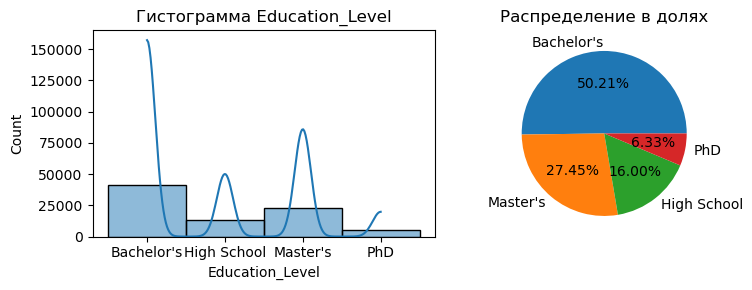

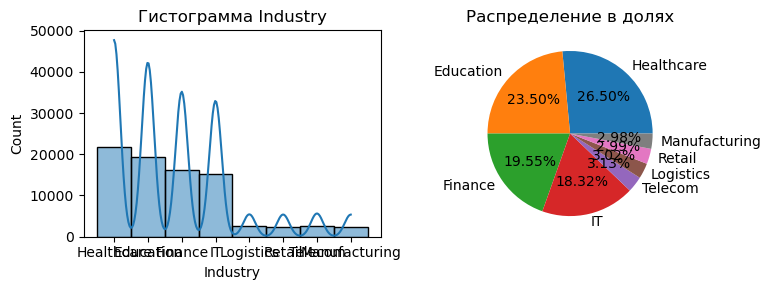

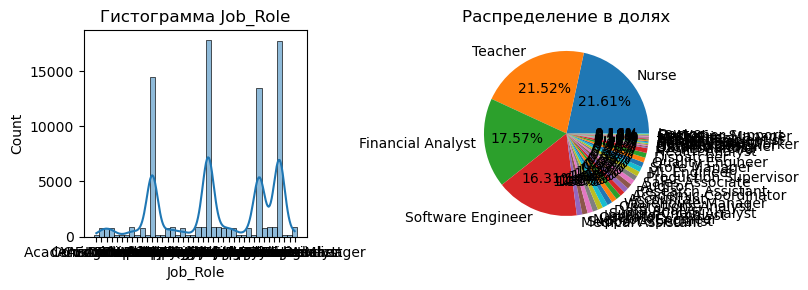

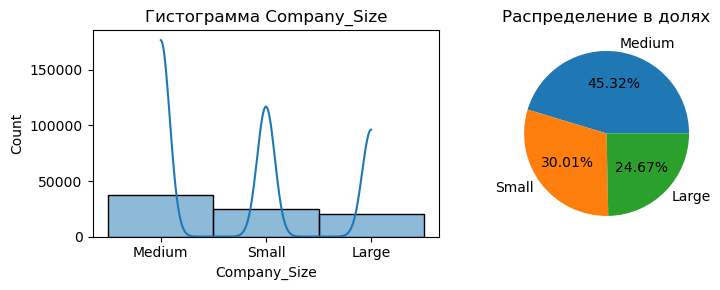

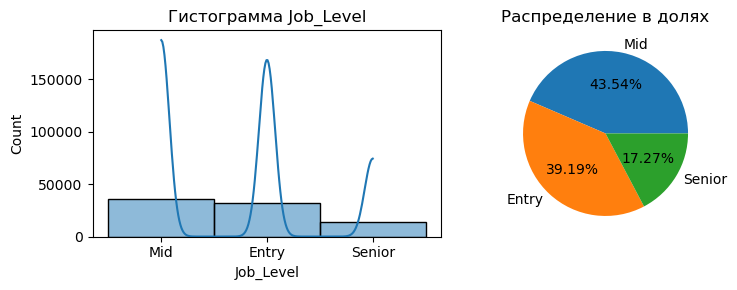

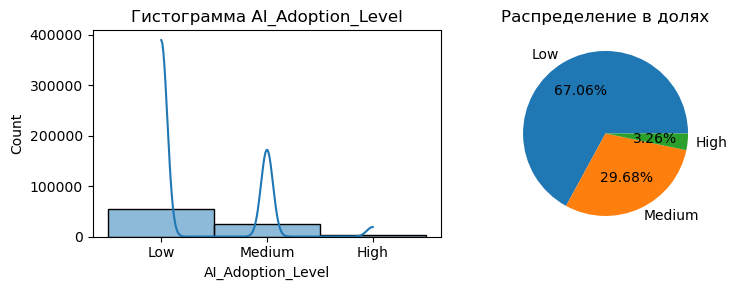

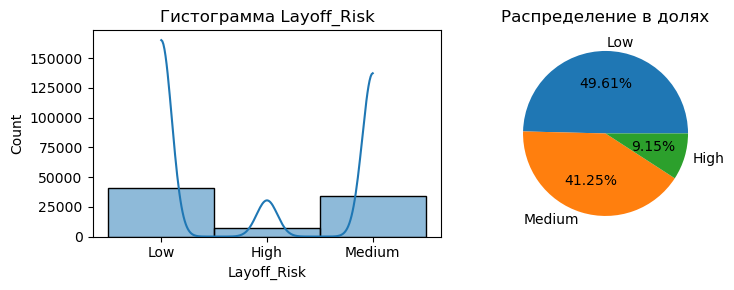

In [ ]:
for col in category_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

    sns.histplot(joined[col], bins='auto', kde=True, ax=ax1)
    ax1.set_title(f'Гистограмма {col}')

    joined[col].value_counts().plot.pie(autopct='%1.2f%%', ax=ax2)
    ax2.set_title(f'Распределение в долях')
    ax2.set_ylabel('')

    plt.tight_layout()
    plt.show()

Вывод: больше всего людей со степенью бакалавра, больше всего людей работает в компаниях среднего размера. Работники сферы здравоохранения представляют собой самую многочисленную группу. Большая часть опрошенных находится в зоне низкого риска увольнения

# Взаимодействие переменных

## Числовая + категориальная: 'Layoff_Risk' + 'Automation_Probability_2030'
Вопрос, поставленный на исследование: зависимость риска увольнения от степени автоматизации к 2030 году

Гипотеза: чем выше степень автоматизации, тем больше вероятность увольнения

In [ ]:
joined.groupby('Layoff_Risk')['Automation_Probability_2030'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Layoff_Risk,,,,,,,,
High,7537.0,0.33,0.16,0.28,0.28,0.28,0.28,0.95
Low,40879.0,0.19,0.08,0.05,0.13,0.20,0.27,0.30
Medium,33988.0,0.46,0.13,0.28,0.34,0.47,0.57,0.70


Основной вывод: Максимальная степень автоматизации в группе с высоким риском увольнения - 95%, средняя - 33%. Группа с низким риском увольнения самая многочисленная при максимальной степени автоматизации в 30%, а средней - 19%. Это может говорить о прямой зависимости риска увольнения от степени автоматизации, подтверждая гипотезу.

Проведем тест на разность значений (берем тест Краскела-Уоллис, т.к. он более устойчив к выбросам, а выбросы, согласно графикам, имеются):

In [ ]:
from scipy.stats import kruskal

groups = [joined[joined['Layoff_Risk'] == i]['Automation_Probability_2030']
          for i in joined['Layoff_Risk'].unique()]
h_stat, p_kw = kruskal(*groups)

print(f"Kruskal-Wallis: H = {h_stat:.2f}, p = {p_kw:.4f}")

Kruskal-Wallis: H = 55346.74, p = 0.0000


Вывод:  H (различие групп Low, Medium и High между собой) указывает на сильные различия между группами, p (вероятность того, что наблюдаемые различия между группами возникли случайно) < 0.001, что говорит о том, что различия статистически значимы.

Построим таблицу сопряжённости между переменными Job_Role и Layoff_Risk, чтобы узнать долю риска каждой профессии (чем выше, тем уязвимее):

In [ ]:
layoff_risk = pd.crosstab(joined['Job_Role'], joined['Layoff_Risk'], normalize='index').round(2).sort_values(by='High', ascending=False)
layoff_risk

Layoff_Risk,High,Low,Medium
Job_Role,,,
Customer Support,1.00,0.00,0.00
Security Guard,0.99,0.00,0.01
Truck Driver,0.98,0.00,0.02
Construction Worker,0.98,0.00,0.02
Retail Worker,0.98,0.00,0.02
Operator,0.50,0.21,0.29
Production Supervisor,0.48,0.18,0.34
Quality Engineer,0.46,0.19,0.35
Inventory Analyst,0.45,0.22,0.34


Вычислим среднюю вероятность автоматизации по профессиям и количество записей, отсортируем среднюю вероятность автоматизации по убыванию:

In [ ]:
auto_probab = joined.groupby('Job_Role')['Automation_Probability_2030'].agg(['mean', 'count']).round(2).sort_values('mean', ascending=False)
auto_probab

,mean,count
Job_Role,,
Retail Worker,0.83,155
Security Guard,0.83,154
Construction Worker,0.83,156
Customer Support,0.83,133
Truck Driver,0.82,153
Graphic Designer,0.53,160
Software Engineer,0.51,13441
Data Scientist,0.50,167
Chef,0.50,141


Объединим таблицы, визуализируем результат:

In [ ]:
comb_tab = auto_probab.join(layoff_risk)
comb_tab

,mean,count,High,Low,Medium
Job_Role,,,,,
Retail Worker,0.83,155,0.98,0.00,0.02
Security Guard,0.83,154,0.99,0.00,0.01
Construction Worker,0.83,156,0.98,0.00,0.02
Customer Support,0.83,133,1.00,0.00,0.00
Truck Driver,0.82,153,0.98,0.00,0.02
Graphic Designer,0.53,160,0.00,0.01,0.99
Software Engineer,0.51,13441,0.02,0.02,0.96
Data Scientist,0.50,167,0.00,0.01,0.99
Chef,0.50,141,0.00,0.00,1.00


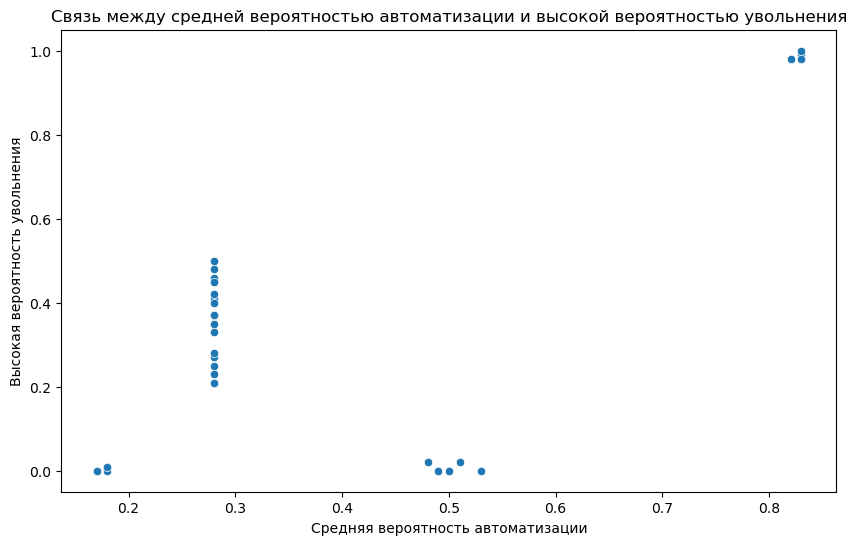

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=comb_tab, x='mean', y='High')
plt.title('Связь между средней вероятностью автоматизации и высокой вероятностью увольнения')
plt.xlabel('Средняя вероятность автоматизации')
plt.ylabel('Высокая вероятность увольнения')
plt.show()

Визуализируем с помощью boxplot:

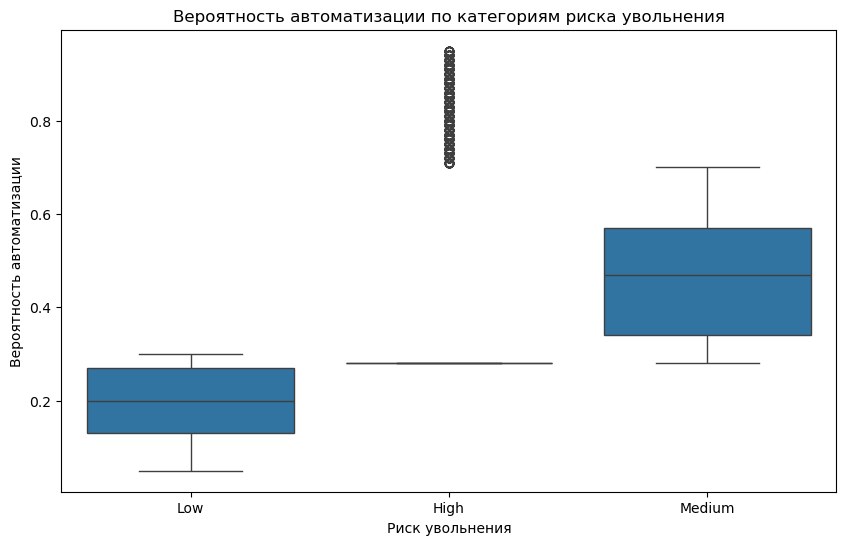

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=joined, x='Layoff_Risk', y='Automation_Probability_2030')
plt.title('Вероятность автоматизации по категориям риска увольнения')
plt.xlabel('Риск увольнения')
plt.ylabel('Вероятность автоматизации')
plt.show()

Вывод: зависимость переменных прямая: чем выше вероятность автоматизации, тем выше риск увольнения

## Категориальная + категориальная: 'Layoff_Risk' + 'Education_Level'
Вопрос, поставленный на исследование: зависимость риска увольнения от занимаемой должности
Гипотеза: вероятность увольнения зависит от уровня образования (чем выше уровень, тем вероятность увольнения меньше)

Построим таблицу сопряжённости между переменными, изменим порядок названий строк и столбцов (для удобства чтения), после чего отсортируем по столбцу High по убыванию:

In [ ]:
crosstab = pd.crosstab(joined['Layoff_Risk'], joined['Education_Level'], normalize=0).round(2)
crosstab = crosstab.loc[['High', 'Medium', 'Low'], ['High School', "Bachelor's", "Master's", 'PhD']]
crosstab

Education_Level,High School,Bachelor's,Master's,PhD
Layoff_Risk,,,,
High,0.24,0.49,0.22,0.05
Medium,0.16,0.55,0.25,0.04
Low,0.14,0.47,0.31,0.08


In [ ]:
high_risk = crosstab.loc['High'].sort_values(ascending=False)
high_risk

Education_Level
Bachelor's     0.49
High School    0.24
Master's       0.22
PhD            0.05
Name: High, dtype: float64

Вывод:

В группе с высоким риском увольнения 49% людей имеет образование бакалавра, 24% – школа, 22% – степень магистра, 5% – PhD.

В группе со средним риском увольнения: 55% имеет образование бакалавра, 16% – школа, 25% – степень магистра, 4% – PhD.

В группе с низким риском увольнения 47% имеет образование бакалавра, 14% – школа, 31% – степень магистра, 8% – PhD.

Среди группы с высоким риском увольнения преобладают бакалавры (49%), далее по убыванию: школа(24%), магистры(22%), PhD(5%).

Построим тепловую таблицу:

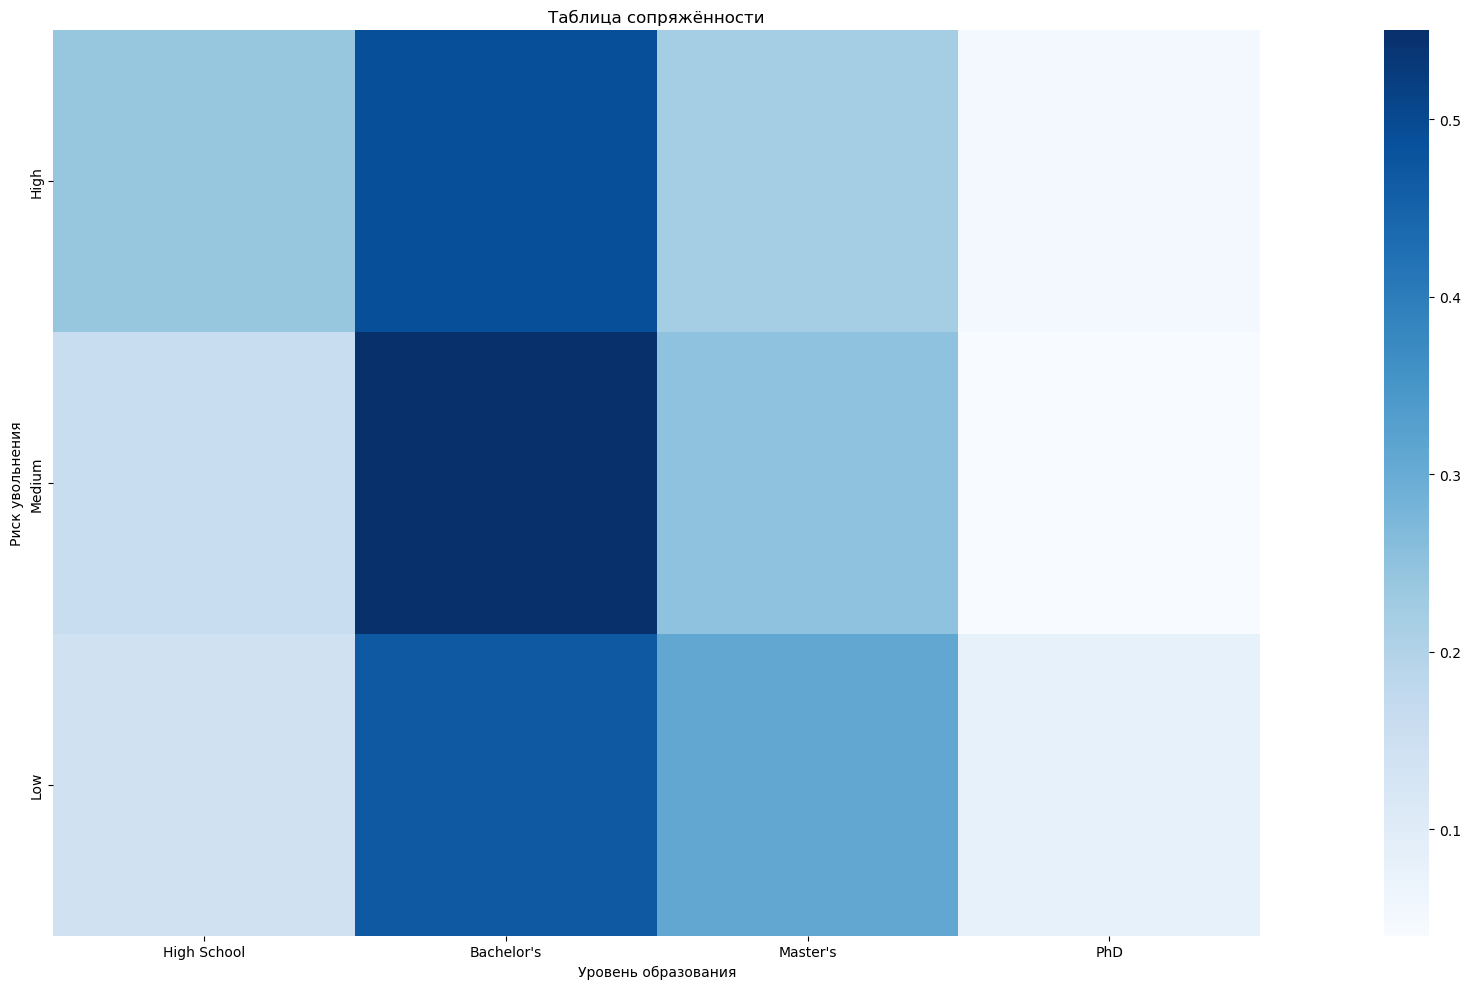

In [ ]:
fig, ax = plt.subplots(figsize=(25,10))
sns.heatmap(crosstab, cmap='Blues', square=True, ax=ax)
plt.title('Таблица сопряжённости')
plt.xlabel('Уровень образования')
plt.ylabel('Риск увольнения')
plt.tight_layout()
plt.show()

Вывод: исходя из представленных данных, можно предположить, что люди с более высоким уровнем образования меньше рискуют попасть под сокращение из-за автоматизации профессии
